In [1]:
%matplotlib widget

In [2]:
%load_ext autoreload

In [3]:
import numpy as np
import panel as pn
from IPython.display import display

In [4]:
pn.extension('tabulator')

In [6]:
from libertem.api import Context

from microscope_calibration.common.model import Model4DSTEM, DescanError, PixelYX
from microscope_calibration.ui import CoordinateCorrectionLayout
from microscope_calibration.util.diffraction import get_twothetas

In [8]:
from hyperspy import api as hs

In [9]:
somefile = hs.load('/storage/er-c-data/adhoc/livecalibration/2026-08-27-CEA-JEOL/raw/MicroscopeCal/mag150kX_cl20cm_ca40um_z30um_roi.dm4', lazy=True)

In [10]:
somefile.metadata

├── Acquisition_instrument
│   └── TEM
│       ├── Stage
│       │   ├── tilt_alpha = -0.385158747434616
│       │   ├── tilt_beta = -0.00148847815580666
│       │   ├── x = 0.0812766799926758
│       │   ├── y = 0.4054736328125
│       │   └── z = 0.0323194580078125
│       ├── acquisition_mode = STEM
│       ├── beam_current = 0.0
│       ├── beam_energy = 200.0
│       ├── camera_length = 200.0
│       ├── dwell_time = 5e-07
│       └── magnification = 150000.0
├── General
│   ├── FileIO
│   │   └── 0
│   │       ├── hyperspy_version = 2.4.0
│   │       ├── io_plugin = rsciio.digitalmicrograph
│   │       ├── operation = load
│   │       └── timestamp = 2026-09-01T14:14:57.544095+02:00
│   ├── date = 2026-08-27
│   ├── original_filename = mag150kX_cl20cm_ca40um_z30um_roi.dm4
│   ├── time = 14:47:10
│   └── title = mag150kX_cl20cm_ca40um_z30um_roi
├── Sample
│   └── description = xgrating-focal-series
└── Signal
    ├── Noise_properties
    │   └── Variance_linear_model
    │       ├── gain_factor = 0.008984725922346115
    │       └── gain_offset = 0.0
    ├── quantity = Electrons (Counts)
    └── signal_type =

In [11]:
import ncempy

In [12]:
somefile2 = ncempy.io.dm.fileDM('/storage/er-c-data/adhoc/livecalibration/2026-08-27-CEA-JEOL/raw/MicroscopeCal/mag150kX_cl20cm_ca40um_z30um_roi.dm4')

In [13]:
somefile2.allTags

{'.ApplicationBounds': array([   0.,    0., 1742., 2718.]),
 '.BackgroundColor': array([-2571., -2571., -1286.]),
 '.DocumentObjectList.1.AnnotationType': np.int32(20),
 '.DocumentObjectList.1.BackgroundColor': array([-1., -1., -1.]),
 '.DocumentObjectList.1.BackgroundMode': np.int16(2),
 '.DocumentObjectList.1.FillMode': np.int16(1),
 '.DocumentObjectList.1.ForegroundColor': array([-1.,  0.,  0.]),
 '.DocumentObjectList.1.HasBackground': np.uint8(0),
 '.DocumentObjectList.1.ImageDisplayInfo.BrightColor': array([-1., -1., -1.]),
 '.DocumentObjectList.1.ImageDisplayInfo.Brightness': np.float32(0.5),
 '.DocumentObjectList.1.ImageDisplayInfo.CaptionOn': np.uint8(0),
 '.DocumentObjectList.1.ImageDisplayInfo.CaptionSize': np.uint16(14),
 '.DocumentObjectList.1.ImageDisplayInfo.CLUT.arraySize': np.uint64(1536),
 '.DocumentObjectList.1.ImageDisplayInfo.CLUT.arrayOffset': 1210,
 '.DocumentObjectList.1.ImageDisplayInfo.CLUT.arrayType': np.float64(2.0),
 '.DocumentObjectList.1.ImageDisplayInfo.C

In [14]:
somefile2.allTags['.ImageList.2.ImageTags.Microscope Info.Voltage']

np.float64(200000.0)

In [15]:
acceleration_voltage_V = somefile2.allTags['.ImageList.2.ImageTags.Microscope Info.Voltage']

In [16]:
# structure_filename = 'BiFeO3EntryWithCollCode29921.cif'
structure_filename = 'AuEntryWithCollCode163723.cif'

In [17]:
twothetas = get_twothetas(structure_filename, acceleration_voltage_V, reciprocal_radius=3)
twothetas

array([0.     , 0.00308, 0.00533, 0.00616, 0.00689, 0.00871, 0.01022,
       0.01067, 0.01232, 0.01343, 0.01377, 0.01509, 0.01601, 0.01742,
       0.01822, 0.01848, 0.01948, 0.0202 , 0.02043, 0.02134, 0.022  ,
       0.02221, 0.02305, 0.02366, 0.02464, 0.02521, 0.0254 , 0.02614,
       0.02668, 0.02685, 0.02755, 0.02806, 0.02823, 0.0289 , 0.02939,
       0.03018, 0.03065, 0.03081, 0.03142, 0.03187, 0.03201, 0.03304,
       0.03318, 0.03375, 0.03417, 0.03485, 0.03526, 0.03539, 0.03593,
       0.03632, 0.03645, 0.03697, 0.03735, 0.03748])

In [18]:
# calib_filename = '/storage/er-c-data/adhoc/libertem/libertem-test-data/default.blo'
# calib_filename = 'with_descan.npy'
calib_filename = '/storage/er-c-data/adhoc/livecalibration/2026-08-27-CEA-JEOL/raw/MicroscopeCal/mag150kX_cl20cm_ca40um_z30um_roi.dm4'

In [19]:
grid = 1e-3 / 2160
grid * 1e9

462.962962962963

In [20]:
ncempy.io.dm.fileDM(calib_filename).allTags

{'.ApplicationBounds': array([   0.,    0., 1742., 2718.]),
 '.BackgroundColor': array([-2571., -2571., -1286.]),
 '.DocumentObjectList.1.AnnotationType': np.int32(20),
 '.DocumentObjectList.1.BackgroundColor': array([-1., -1., -1.]),
 '.DocumentObjectList.1.BackgroundMode': np.int16(2),
 '.DocumentObjectList.1.FillMode': np.int16(1),
 '.DocumentObjectList.1.ForegroundColor': array([-1.,  0.,  0.]),
 '.DocumentObjectList.1.HasBackground': np.uint8(0),
 '.DocumentObjectList.1.ImageDisplayInfo.BrightColor': array([-1., -1., -1.]),
 '.DocumentObjectList.1.ImageDisplayInfo.Brightness': np.float32(0.5),
 '.DocumentObjectList.1.ImageDisplayInfo.CaptionOn': np.uint8(0),
 '.DocumentObjectList.1.ImageDisplayInfo.CaptionSize': np.uint16(14),
 '.DocumentObjectList.1.ImageDisplayInfo.CLUT.arraySize': np.uint64(1536),
 '.DocumentObjectList.1.ImageDisplayInfo.CLUT.arrayOffset': 1210,
 '.DocumentObjectList.1.ImageDisplayInfo.CLUT.arrayType': np.float64(2.0),
 '.DocumentObjectList.1.ImageDisplayInfo.C

In [21]:
#ctx = Context.make_with(cpus=8)
ctx = Context.make_with('inline')

In [22]:
ds = ctx.load('auto', calib_filename)

In [25]:
start_model = None

In [26]:
%autoreload
gui = CoordinateCorrectionLayout(
    dataset=ds,
    nav_mode='sumsig',
    sig_mode='log',
    ctx=ctx,
    start_model=start_model,
#    twothetas=twothetas,
    # twothetas=np.array([0.,1.]),
    # twothetas=None,
    twothetas=twothetas,
)
display(gui.layout.servable())

NotImplementedError: JAX Arrays do not implement the arr.flat property: consider arr.flatten() instead.

In [43]:
curr_params = gui.params

In [79]:
gui.params

Parameters4DSTEM(overfocus=0.0, scan_pixel_pitch=3.687427226397054e-08, scan_center=PixelYX(y=16.0, x=16.0), scan_rotation=0.0, camera_length=0.2, detector_pixel_pitch=5e-05, detector_center=PixelYX(y=128.0, x=128.0), semiconv=0.0, flip_factor=1.0, descan_error=DescanError(pxo_pxi=0.0, pxo_pyi=0.0, pyo_pxi=0.0, pyo_pyi=0.0, sxo_pxi=0.0, sxo_pyi=0.0, syo_pxi=0.0, syo_pyi=0.0, offpxi=0.0, offpyi=0.0, offsxi=0.0, offsyi=0.0), detector_rotation=0.0)

In [32]:
calib_filename_2 = '/storage/er-c-data/adhoc/livecalibration/2025-11-21-hitachidata/unzipped/Camera length_3/data.npy'

In [33]:
calib_meta_2 = '/storage/er-c-data/adhoc/livecalibration/2025-11-21-hitachidata/unzipped/Camera length_3/meta_data.npy'

In [35]:
meta_2 = np.load(calib_meta_2, allow_pickle=True)

In [36]:
meta_2[0]

{'ref_size': (256, 256, 2299.5087719298244, 2299.5087719298244),
 'roi.offset': (24, 23),
 'scan_generator.area': (0.5614035087719298, 0.5614035087719298),
 'scan_generator.area_offset': (0.42105263157894735, 0.40350877192982454),
 'scan_generator.pixel_factors': (71.85964912280701, 71.85964912280701),
 'content.types': ['CameraX', 'CameraY', 'ScanX', 'ScanY'],
 'type': '2D',
 'source.trigger_source': 'Camera',
 'scan_generator.magnification_factor': 1.0,
 'scan_generator.shutter': True,
 'scan_generator.fluscreen': False,
 'scan_generator.rotation': 0.0,
 'scan_generator.xamplitude': 6.0,
 'scan_generator.yamplitude': 6.0,
 'scan_generator.xoffset_voltage': 0.0,
 'scan_generator.yoffset_voltage': 0.0,
 'scan_generator.enable_dig2_trigger_output': True,
 'scan_generator.scan_gen_version': 329,
 'scan_generator.pixel_delay': 0.0,
 'scan_generator.line_delay': 0.0005,
 'scan_generator.sync_delay': 0.0,
 'scan_generator.sync': False,
 'scan_generator.pre_line_pixels': 0,
 'scan_generator.

In [41]:
scale_factor = meta[0]['scan_driver.magnification'] / meta_2[0]['scan_driver.magnification']

In [42]:
scale_factor

16.666666666666668

In [44]:
next_params = curr_params.derive(scan_pixel_pitch=curr_params.scan_pixel_pitch*scale_factor)

In [45]:
next_ds = ctx.load('auto', path=calib_filename_2)

Column
    [0] Markdown(str, max_width=500)
    [1] Row
        [0] FloatInput(name='Scan rotation / degrees')
        [1] FloatInput(name='Detector pixel p..., value=55.0)
        [2] FloatInput(name='Camera length / m', step=0.01, value=0.2)
        [3] FloatInput(name='Convergence s..., step=0.01)
    [2] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['74061d3c-8e29-41ca-910d-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['3db6c6ad-c1fc-4f25-8cbe-...], visible=False, width=2)
            [1] Bokeh(figure)
    [3] Column
        [0] Markdown(str)
        [1] Tabulator(buttons={'select': '<i class="fa f...}, selectable=False, value=Empty DataFrame
Columns: [...)
        [2] Row
            [0] Button(name='Record')
            [1] Button(name='Apply correction f...)
            [2] Button(name='Clear')
            [3] Button(name='Refine correction w...)
    [4] Markdown(str, max_width=500)
    [5] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['f9912f82-8430-4dfb-9815-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['f06b7f8c-477c-4875-9b70-...], visible=False, width=2)
            [1] Bokeh(figure)
        [2] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['e848d325-d699-49df-9713-...], visible=False, width=2)
            [1] Bokeh(figure)
    [6] Row
        [0] FloatInput(name='Scale bar / nm', step=0.01, value=np.float64(12502.687322592...)
    [7] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['b52a43b4-
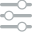
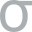
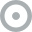
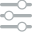
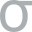
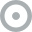
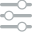
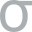
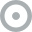
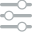
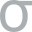
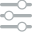
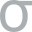
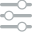
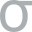
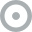
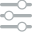
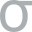
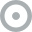
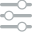
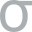
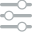
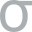

In [62]:
%autoreload
next_gui = CoordinateCorrectionLayout(
    dataset=next_ds,
    nav_mode='sumsig',
    sig_mode='log',
    ctx=ctx,
    start_params=next_params,
#    twothetas=twothetas,
    # twothetas=np.array([0.,1.]),
    # twothetas=None,
    #twothetas=twothetas,
)
display(next_gui.layout.servable())

In [63]:
overfocus_tmp_params = next_gui.params

In [78]:
overfocus_tmp_params

Parameters4DSTEM(overfocus=0.0, scan_pixel_pitch=5.581556840442885e-07, scan_center=PixelYX(y=16.0, x=16.0), scan_rotation=0.0, camera_length=0.2, detector_pixel_pitch=5.5e-05, detector_center=PixelYX(y=128.0, x=128.0), semiconv=0.003, flip_factor=1.0, descan_error=DescanError(pxo_pxi=0.0, pxo_pyi=0.0, pyo_pxi=0.0, pyo_pyi=0.0, sxo_pxi=239.7375969655201, sxo_pyi=10.965416027941375, syo_pxi=-56.51838739519673, syo_pyi=204.356127368837, offpxi=0.0, offpyi=0.0, offsxi=0.0028276374816883026, offsyi=0.0026894734382619094), detector_rotation=0.0)

In [64]:
overfocus_filename = '/storage/er-c-data/adhoc/livecalibration/2025-11-21-hitachidata/unzipped/Overfocus_1/data.npy'

In [65]:
overfocus_meta_filename = '/storage/er-c-data/adhoc/livecalibration/2025-11-21-hitachidata/unzipped/Overfocus_1/meta_data.npy'

In [66]:
overfocus_meta = np.load(overfocus_meta_filename, allow_pickle=True)
overfocus_meta[0]

{'ref_size': (256, 256, 4096.0, 4096.0),
 'roi.offset': (0, 0),
 'scan_generator.area': (1.0, 1.0),
 'scan_generator.area_offset': (0.0, 0.0),
 'scan_generator.pixel_factors': (128.0, 128.0),
 'content.types': ['CameraX', 'CameraY', 'ScanX', 'ScanY'],
 'type': '2D',
 'source.trigger_source': 'Camera',
 'scan_generator.magnification_factor': 1.0,
 'scan_generator.shutter': True,
 'scan_generator.fluscreen': False,
 'scan_generator.rotation': 0.0,
 'scan_generator.xamplitude': 6.0,
 'scan_generator.yamplitude': 6.0,
 'scan_generator.xoffset_voltage': 0.0,
 'scan_generator.yoffset_voltage': 0.0,
 'scan_generator.enable_dig2_trigger_output': True,
 'scan_generator.scan_gen_version': 329,
 'scan_generator.pixel_delay': 0.0,
 'scan_generator.line_delay': 0.0005,
 'scan_generator.sync_delay': 0.0,
 'scan_generator.sync': False,
 'scan_generator.pre_line_pixels': 0,
 'scan_generator.scangen_pixel_overhead': 2.5e-06,
 'scan_generator.elf_pixel_overhead': 3.6e-06,
 'scan_generator.sampling_patte

In [67]:
overfocus_params = overfocus_tmp_params.derive(
    scan_pixel_pitch=curr_params.scan_pixel_pitch * meta[0]['scan_driver.magnification'] / overfocus_meta[0]['scan_driver.magnification']
)

In [68]:
overfocus_ds = ctx.load('auto', path=overfocus_filename)

Column
    [0] Markdown(str, max_width=500)
    [1] Row
        [0] FloatInput(name='Scan rotation / degrees')
        [1] FloatInput(name='Detector pixel p..., value=55.0)
        [2] FloatInput(name='Camera length / m', step=0.01, value=0.3)
        [3] FloatInput(name='Convergence s..., step=0.01, value=3.0)
    [2] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['3a3b9a82-bf2d-44c3-b21e-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['c528a2df-9193-4327-9b57-...], visible=False, width=2)
            [1] Bokeh(figure)
    [3] Column
        [0] Markdown(str)
        [1] Tabulator(buttons={'select': '<i class="fa f...}, selectable=False, value=Empty DataFrame
Columns: [...)
        [2] Row
            [0] Button(name='Record')
            [1] Button(name='Apply correction f...)
            [2] Button(name='Clear')
            [3] Button(name='Refine correction w...)
    [4] Markdown(str, max_width=500)
    [5] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['045f0bf3-5755-4d03-ae76-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['908d0468-5600-4306-ade7-...], visible=False, width=2)
            [1] Bokeh(figure)
        [2] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['65728b0d-8d64-42ca-84f5-...], visible=False, width=2)
            [1] Bokeh(figure)
    [6] Row
        [0] FloatInput(name='Scale bar / nm', step=0.01, value=np.float64(1071.6589133650...)
    [7] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(name='...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=
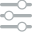
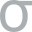
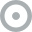
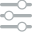
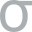
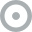
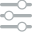
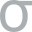
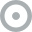
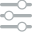
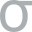
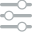
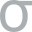
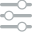
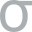
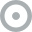
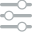
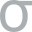
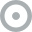
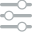
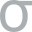
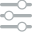
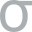

In [74]:
%autoreload
overfocus_gui = CoordinateCorrectionLayout(
    dataset=overfocus_ds,
    nav_mode='point',
    sig_mode='lin',
    ctx=ctx,
    # start_params=overfocus_params,
    start_params=my_params,
#    twothetas=twothetas,
    # twothetas=np.array([0.,1.]),
    # twothetas=None,
    #twothetas=twothetas,
)
display(overfocus_gui.layout.servable())

In [75]:
overfocus_gui.params

Parameters4DSTEM(overfocus=-3.449588114772323e-05, scan_pixel_pitch=4.7841915775224705e-08, scan_center=PixelYX(y=16.0, x=16.0), scan_rotation=-0.09048322199089257, camera_length=0.2, detector_pixel_pitch=5.5e-05, detector_center=PixelYX(y=128.0, x=128.0), semiconv=0.003, flip_factor=0.9999840851173577, descan_error=DescanError(pxo_pxi=0.0, pxo_pyi=0.0, pyo_pxi=0.0, pyo_pyi=0.0, sxo_pxi=-377.7173350791781, sxo_pyi=536.3844098675578, syo_pxi=-378.05573982278344, syo_pyi=133.05840338664856, offpxi=0.0, offpyi=0.0, offsxi=0.0001345311731517336, offsyi=0.0002895995018306298), detector_rotation=-0.18990638264627405)

In [72]:
my_params = overfocus_gui.params

In [20]:
from typing import NamedTuple

import jax.numpy as jnp
import optimistix

from microscope_calibration.common.model import trace

In [21]:
class _CoordPointArgs(NamedTuple):
    params: Parameters4DSTEM
    # [(scan_y, scan_x, detector_y, detector_x) * n]
    points: jnp.array

In [22]:
def _coords_point_loss(y, args: _CoordPointArgs):
    detector_rotation, overfocus, flip_factor = y[:3]
    tilts = y[3:]

    assert len(tilts) == 2 * len(points)
    
    opt_params = args.params.derive(
        detector_rotation=detector_rotation,
        overfocus=overfocus,
        flip_factor=flip_factor,
    )

    detector_distances = []
    specimen_hits = []
    for i, (scan_y, scan_x, det_y, det_x) in enumerate(args.points):
        dy, dx = tilts[2*i:2*i + 2]
        res = trace(
            opt_params, scan_pos=PixelYX(y=scan_y, x=scan_x), source_dx=dx, source_dy=dy)
        detector_distances.extend((
            det_y - res['detector'].sampling['detector_px'].y,
            det_x - res['detector'].sampling['detector_px'].x,
        ))
        specimen_hits.append((
            res['specimen'].sampling['scan_px'].y,
            res['specimen'].sampling['scan_px'].x
        ))
    specimen_arr = jnp.array(specimen_hits)
    specimen_var = jnp.var(specimen_arr, axis=0)
    aspect = jnp.array((jnp.abs(jnp.abs(flip_factor) - 1) * 100, ))
    return jnp.concatenate((jnp.array(detector_distances), specimen_var, aspect))

In [23]:
points = gui.coord_fixpoint_table.value.reset_index().to_numpy()

In [24]:
points

array([], shape=(0, 6), dtype=object)

In [25]:
params = gui.params

In [26]:
def solve_coords_points(ref_params: Parameters4DSTEM, points: jnp.ndarray):
    args = _CoordPointArgs(
        params=ref_params,
        points=points,
    )

    start = jnp.array([ref_params.detector_rotation, ref_params.overfocus, ref_params.flip_factor] + [0., 0.] * len(points))
    opt_res = optimistix.least_squares(
        fn=_coords_point_loss,
        args=args,
        # FIXME Doesn't reach 1e-12 like the others, for unknown reasons
        solver=optimistix.BFGS(atol=1e-11, rtol=1e-11),
        y0=start,
        # FIXME needs more steps than others, for unknown reasons
        max_steps=10000,
    )
    residual = _coords_point_loss(opt_res.value, args)
    # Write the new tilts and offsets into the previous descan error
    detector_rotation, overfocus, flip_factor = opt_res.value[:3]
    res_params = ref_params.derive(
        detector_rotation=detector_rotation,
        overfocus=overfocus,
        flip_factor=flip_factor,
    ).normalize_types()

    return res_params, residual

In [27]:
new_param, residuals = solve_coords_points(params, points)

TypeError: Error interpreting argument to <function least_squares at 0x7fa5d559ff60> as an abstract array. The problematic value is of type <class 'numpy.ndarray'> and was passed to the function at path dynamic_nodonate['rest'][33].
This typically means that a jit-wrapped function was called with a non-array argument, and this argument was not marked as static using the static_argnums or static_argnames parameters of jax.jit.

In [ ]:
gui.update_with_force(gui.model_params, gui.params_update(new_param))